# sEMG Preprocessing Explorer

Exploratory preprocessing for fatigue / proximity-to-failure (RIR) estimation.

**Goal:** walk one max-effort recording through a practical pipeline and visualize the signals that matter for the hypothesis:

- RMS / amplitude rising toward failure
- median / mean frequency drifting down
- time-frequency content becoming less stationary

**Pipeline:** load → uniform resample → band-pass → notch → spike cleanup → window → features

**NOTE:** The data explored in this file (`max_set3.csv`) is not representative of the data we will analyze in the future. This is purely for developing the preprocessing/visualization pipeline

In [ ]:
# Import Libraries

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import (
    butter,
    sosfiltfilt,
    filtfilt,
    iirnotch,
    welch,
    spectrogram,
    hilbert,
)

# Set Matplotlib Parameters
plt.rcParams.update({
    "figure.figsize": (12, 3.5),
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# Define Constants
DATA_PATH = Path("../data/max_set3.csv")
FS = 1000  # firmware target sample rate (Hz)
BANDPASS = (20, 450)
NOTCH_HZ = 60
NOTCH_Q = 30
WINDOW_MS = 256
STEP_MS = 128
SPIKE_N_STD = 4

# Load Data
print(f"Loading {DATA_PATH.resolve()}")

Loading /Users/macairm3/Projects/muscle-activation/data/max_set3.csv


## 1. Load, clean timestamps, resample to uniform grid

Firmware aims for 1000 Hz, but serial drops create ~10 ms gaps. Filtering assumes uniform sampling, so we interpolate onto a regular 1 ms grid before anything else.

In [2]:
# Load the Raw Data
raw = pd.read_csv(DATA_PATH)

# Convert columns to numeric values
# errors="coerce" will convert non-numeric values to NaN and dropna() will remove rows with NaN values
raw["timestamp_us"] = pd.to_numeric(raw["timestamp_us"], errors="coerce")
raw["adc_raw"] = pd.to_numeric(raw["adc_raw"], errors="coerce")
raw = raw.dropna().reset_index(drop=True)

# Calculate the time difference between consecutive rows and the median time difference
dt_us = np.diff(raw["timestamp_us"].to_numpy())
median_dt = np.median(dt_us)

# Check if the first row has a bogus early timestamp and drop it if so
bad_first = raw["timestamp_us"].iloc[0] < raw["timestamp_us"].iloc[1] - 1_000_000
if bad_first:
    raw = raw.iloc[1:].reset_index(drop=True)
    dt_us = np.diff(raw["timestamp_us"].to_numpy())

# Convert the timestamp to seconds and the adc_raw to a numpy array
t_raw = (raw["timestamp_us"] - raw["timestamp_us"].iloc[0]).to_numpy(dtype=float) / 1e6
x_raw = raw["adc_raw"].to_numpy(dtype=float)

# Create evenly spaced timestamps
t = np.arange(0, t_raw[-1], 1 / FS)
# Interpolate the raw data onto the evenly spaced timestamps
x = np.interp(t, t_raw, x_raw)

# Print the number of samples in the raw data and the duration of the recording
print(f"Samples (file): {len(raw)}")
print(f"Duration: {t_raw[-1]:.2f} s")
print(f"Median dt: {median_dt:.0f} us  |  gaps > 2 ms: {(dt_us > 2000).sum()}")
print(f"Resampled length @ {FS} Hz: {len(x)} samples")
raw.head()

Samples (file): 7920
Duration: 11.68 s
Median dt: 1000 us  |  gaps > 2 ms: 399
Resampled length @ 1000 Hz: 11684 samples


,timestamp_us,adc_raw
0,1260826698,1822
1,1260827698,1777
2,1260828698,1753
3,1260829698,1783
4,1260830698,1814


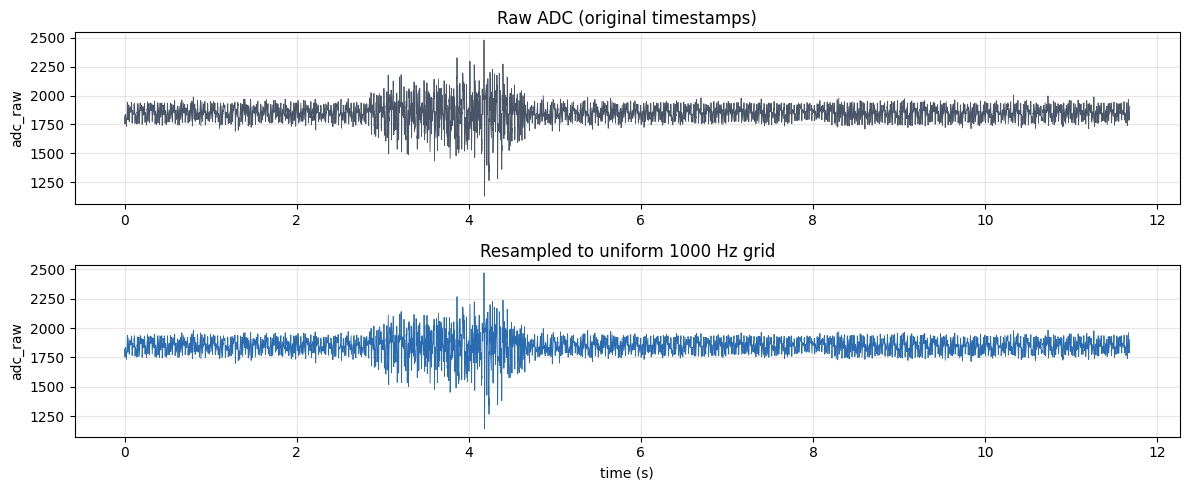

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=False)

axes[0].plot(t_raw, x_raw, lw=0.6, color="#4a5568")
axes[0].set_title("Raw ADC (original timestamps)")
axes[0].set_ylabel("adc_raw")

axes[1].plot(t, x, lw=0.6, color="#2b6cb0")
axes[1].set_title(f"Resampled to uniform {FS} Hz grid")
axes[1].set_xlabel("time (s)")
axes[1].set_ylabel("adc_raw")

fig.tight_layout()
plt.show()

## 2. Band-pass + notch filtering

- **Band-pass 20–450 Hz** (4th-order Butterworth, zero-phase): remove motion / baseline drift and high-frequency noise.
- **60 Hz notch** (Q=30, zero-phase): remove US powerline hum.

These are the conditioning steps described in the study protocol before feature extraction.

In [4]:
# Define the butterworth bandpass filter
# 
def bandpass(signal, low, high, fs, order=2):
    sos = butter(order, [low, high], btype="bandpass", fs=fs, output="sos")
    return sosfiltfilt(sos, signal)


def notch(signal, freq, fs, q=30):
    b, a = iirnotch(freq, q, fs=fs)
    return filtfilt(b, a, signal)


x_bp = bandpass(x, *BANDPASS, fs=FS)
x_filt = notch(x_bp, NOTCH_HZ, fs=FS, q=NOTCH_Q)

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
axes[0].plot(t, x - x.mean(), lw=0.5, color="#718096")
axes[0].set_title("Mean-centered raw (resampled)")
axes[0].set_ylabel("ADC")

axes[1].plot(t, x_bp, lw=0.5, color="#2b6cb0")
axes[1].set_title(f"Band-pass {BANDPASS[0]}–{BANDPASS[1]} Hz")
axes[1].set_ylabel("ADC")

axes[2].plot(t, x_filt, lw=0.5, color="#276749")
axes[2].set_title(f"+ {NOTCH_HZ} Hz notch")
axes[2].set_xlabel("time (s)")
axes[2].set_ylabel("ADC")

fig.tight_layout()
plt.show()

NameError: name 'filtfilt' is not defined

In [ ]:
def plot_psd(ax, signal, fs, label, color):
    freqs, psd = welch(signal, fs=fs, nperseg=min(1024, len(signal)))
    ax.semilogy(freqs, psd, label=label, color=color, lw=1.2)
    return freqs, psd


fig, ax = plt.subplots(figsize=(12, 4))
plot_psd(ax, x - x.mean(), FS, "raw (mean-centered)", "#a0aec0")
plot_psd(ax, x_bp, FS, "band-pass", "#2b6cb0")
plot_psd(ax, x_filt, FS, "band-pass + notch", "#276749")
ax.axvline(NOTCH_HZ, color="crimson", ls="--", lw=1, label=f"{NOTCH_HZ} Hz")
ax.axvspan(BANDPASS[0], BANDPASS[1], color="#68d391", alpha=0.12, label="passband")
ax.set_xlim(0, 500)
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("PSD")
ax.set_title("Power spectral density before / after filtering")
ax.legend()
fig.tight_layout()
plt.show()

## 3. Spike cleanup

Heavy dynamic reps can produce brief electrode / cable spikes. Samples beyond ±N standard deviations are interpolated rather than hard-deleted so the time base stays intact.

In [ ]:
def remove_spikes(signal, n_std=4):
    mu = np.mean(signal)
    sigma = np.std(signal)
    mask = np.abs(signal - mu) <= n_std * sigma
    cleaned = signal.copy()
    if (~mask).any():
        idx = np.arange(len(signal))
        cleaned[~mask] = np.interp(idx[~mask], idx[mask], signal[mask])
    return cleaned, mask


x_clean, spike_mask = remove_spikes(x_filt, n_std=SPIKE_N_STD)
n_spikes = (~spike_mask).sum()
print(f"Interpolated spikes: {n_spikes} ({100 * n_spikes / len(x_clean):.2f}% of samples)")

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(t, x_filt, lw=0.5, color="#a0aec0", label="filtered")
ax.plot(t, x_clean, lw=0.7, color="#276749", label="spike-cleaned")
if n_spikes:
    ax.scatter(t[~spike_mask], x_filt[~spike_mask], s=12, c="crimson", zorder=3, label="spikes")
ax.set_xlabel("time (s)")
ax.set_ylabel("ADC")
ax.set_title(f"Spike cleanup (±{SPIKE_N_STD} SD)")
ax.legend()
fig.tight_layout()
plt.show()

## 4. Amplitude envelope (fatigue-relevant view)

As a set approaches failure, neural drive typically rises and **RMS / envelope amplitude increases**.
A smoothed Hilbert envelope makes that progression easier to see than the raw oscillatory sEMG.

In [ ]:
analytic = hilbert(x_clean)
envelope = np.abs(analytic)

# Light smoother (~100 ms moving average) for readability
smooth_n = max(1, int(0.1 * FS))
kernel = np.ones(smooth_n) / smooth_n
envelope_s = np.convolve(envelope, kernel, mode="same")

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(t, x_clean, lw=0.35, color="#a0aec0", label="cleaned sEMG")
ax.plot(t, envelope_s, lw=1.5, color="#c05621", label="smoothed envelope")
ax.set_xlabel("time (s)")
ax.set_ylabel("ADC")
ax.set_title("Filtered signal + amplitude envelope")
ax.legend()
fig.tight_layout()
plt.show()

## 5. Sliding windows + feature extraction

Default: **256 ms windows**, **50% overlap** (128 ms step). Each window becomes one feature vector for later ML.

Features chosen to match the fatigue / RIR hypothesis:

| Feature | Domain | Expected near failure |
|---------|--------|------------------------|
| RMS, MAV | time | ↑ amplitude / drive |
| WL | time | ↑ complexity |
| ZC, SSC | time | rough frequency proxies |
| MNF, MDF | frequency | ↓ as conduction velocity falls |

In [ ]:
def zero_crossings(w, eps):
    prod = w[:-1] * w[1:]
    return int(np.sum((prod < 0) & (np.abs(np.diff(w)) >= eps)))


def slope_sign_changes(w, eps):
    d1 = w[1:-1] - w[:-2]
    d2 = w[1:-1] - w[2:]
    return int(np.sum((d1 * d2) >= eps))


def mean_freq(w, fs):
    freqs, psd = welch(w, fs=fs, nperseg=len(w))
    denom = np.sum(psd)
    if denom <= 0:
        return np.nan
    return float(np.sum(freqs * psd) / denom)


def median_freq(w, fs):
    freqs, psd = welch(w, fs=fs, nperseg=len(w))
    csum = np.cumsum(psd)
    if csum[-1] <= 0:
        return np.nan
    return float(freqs[np.searchsorted(csum, csum[-1] / 2)])


def extract_features(signal, fs, window_ms=256, step_ms=128):
    win = int(window_ms * fs / 1000)
    step = int(step_ms * fs / 1000)
    rows = []
    for start in range(0, len(signal) - win + 1, step):
        w = signal[start : start + win]
        eps = 0.01 * np.std(w)
        rows.append({
            "t_start_s": start / fs,
            "t_center_s": (start + win / 2) / fs,
            "mav": float(np.mean(np.abs(w))),
            "rms": float(np.sqrt(np.mean(w ** 2))),
            "wl": float(np.sum(np.abs(np.diff(w)))),
            "zc": zero_crossings(w, eps),
            "ssc": slope_sign_changes(w, eps),
            "mnf": mean_freq(w, fs),
            "mdf": median_freq(w, fs),
        })
    return pd.DataFrame(rows)


features = extract_features(x_clean, FS, WINDOW_MS, STEP_MS)
print(f"Windows: {len(features)}  ({WINDOW_MS} ms, step {STEP_MS} ms)")
features.head()

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(features["t_center_s"], features["rms"], marker="o", ms=3, lw=1, color="#c05621")
axes[0].plot(features["t_center_s"], features["mav"], marker="o", ms=3, lw=1, color="#dd6b20", alpha=0.7)
axes[0].set_ylabel("amplitude")
axes[0].set_title("Amplitude features over the set (expect ↑ toward failure)")
axes[0].legend(["RMS", "MAV"])

axes[1].plot(features["t_center_s"], features["mdf"], marker="o", ms=3, lw=1, color="#2b6cb0")
axes[1].plot(features["t_center_s"], features["mnf"], marker="o", ms=3, lw=1, color="#3182ce", alpha=0.7)
axes[1].set_ylabel("Hz")
axes[1].set_title("Spectral features over the set (expect ↓ toward failure)")
axes[1].legend(["MDF", "MNF"])

axes[2].plot(features["t_center_s"], features["wl"], marker="o", ms=3, lw=1, color="#553c9a")
axes[2].set_xlabel("time (s)")
axes[2].set_ylabel("WL")
axes[2].set_title("Waveform length (complexity)")

fig.tight_layout()
plt.show()

features.describe().T

## 6. Spectrogram (nonstationarity)

Fatigue should redistribute spectral power over time. A spectrogram is a quick visual check that frequency content is changing across the set, not just overall amplitude.

In [ ]:
f_s, t_s, Sxx = spectrogram(
    x_clean,
    fs=FS,
    nperseg=256,
    noverlap=128,
    scaling="spectrum",
)

fig, ax = plt.subplots(figsize=(12, 4))
pcm = ax.pcolormesh(
    t_s,
    f_s,
    10 * np.log10(Sxx + 1e-12),
    shading="auto",
    cmap="viridis",
)
ax.set_ylim(0, 450)
ax.set_xlabel("time (s)")
ax.set_ylabel("frequency (Hz)")
ax.set_title("Spectrogram of cleaned sEMG")
fig.colorbar(pcm, ax=ax, label="power (dB)")
fig.tight_layout()
plt.show()

## 7. Peak-dynamic normalization preview

For cross-session / cross-exercise ML later, scale amplitude features by the set's peak RMS (task-specific dynamic normalization from the research notes). Frequency features are left unscaled.

In [ ]:
peak_rms = features["rms"].max()
norm = features.copy()
for col in ["mav", "rms", "wl"]:
    norm[f"{col}_norm"] = norm[col] / peak_rms

print(f"Peak RMS this set: {peak_rms:.2f}")

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(norm["t_center_s"], norm["rms_norm"], marker="o", ms=3, lw=1, color="#c05621")
ax.plot(norm["t_center_s"], norm["mav_norm"], marker="o", ms=3, lw=1, color="#dd6b20", alpha=0.7)
ax.set_xlabel("time (s)")
ax.set_ylabel("fraction of peak RMS")
ax.set_title("Peak-dynamic normalized amplitude features")
ax.legend(["RMS / peak", "MAV / peak"])
fig.tight_layout()
plt.show()

norm.head()

## Takeaways for the RIR pipeline

1. **Always resample** this firmware output before filtering - gaps break Butterworth / notch assumptions.
2. **Band-pass + notch** is the baseline conditioner from the protocol.
3. **Windowed RMS / MAV / MDF / MNF** are the first features to watch for 0–3 RIR labels once reps are annotated.
4. Next data work: mark each repetition boundary (and ideally concentric vs eccentric), label RIR from failure, then train on window features grouped by subject / set so overlapping windows do not leak.

This notebook is exploratory only - no classifier yet.